# Notebook 02 — Preprocesamiento

**Proyecto:** Predicción de Riesgo de Incumplimiento Crediticio  
**Inputs:** `data/raw/CreditScoring.csv` · `r_analysis/outputs/iv_table.csv`  
**Outputs:** `data/processed/data_clean.csv` · `data/processed/data_smote.csv`

Este notebook toma el dataset crudo, aplica todas las correcciones identificadas en el EDA y el análisis de IV de R, y produce los datos listos para el modelado.

---

## Índice
1. Carga de librerías y datos
2. Selección de variables según IV
3. Tratamiento de anomalías y errores
4. Imputación de valores nulos
5. Winsorización de outliers
6. Exportar dataset limpio
7. Split train / test
8. Balanceo de clases con SMOTE
9. Verificación final y exportación

---
## 1. Carga de librerías y datos

**Justificación técnica (Eliminación de ID):** Mantener el identificador único `ID` podría inducir al algoritmo a aprender patrones espurios dependientes del orden de registro. Se remueve para asegurar la generalización del modelo basada únicamente en variables de perfil crediticio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Semilla global para reproducibilidad
SEED = 42

# Carga del dataset crudo
df = pd.read_csv('../data/raw/CreditScoring.csv')
df.drop(columns=['ID'], inplace=True)

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 150,000 filas x 11 columnas


---
## 2. Selección de variables según IV

Cargamos la tabla de IV generada por el script R. Solo conservamos las variables con **IV>=0.02** (poder predictivo débil o mayor).
> Si aún no se ha ejecutado el script R, comentar el bloque de carga del CSV de IV y usar lista manual definida más abajo,

In [2]:
TARGET = 'SeriousDlqin2yrs'

try:
    # Opción A: cargar desde el output del script R
    iv_tabla = pd.read_csv('../r_analysis/outputs/iv_tabla.csv')
    vars_seleccionadas = iv_tabla[iv_tabla['iv'] >= 0.02]['variable'].tolist()
    vars_seleccionadas = [v.replace('.', '-') for v in vars_seleccionadas]
    print('Variables cargadas desde iv_tabla.csv:')

except FileNotFoundError:
    # Opción B: lista manual basada en correlaciones del EDA
    # (usar hasta ejecutar el script R)
    vars_seleccionadas = [
        'RevolvingUtilizationOfUnsecuredLines',
        'age',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'DebtRatio',
        'MonthlyIncome',
        'NumberOfOpenCreditLinesAndLoans',
        'NumberOfTimes90DaysLate',
        'NumberRealEstateLoansOrLines',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfDependents'
    ]
    print('iv_tabla.csv no encontrado — usando lista manual del EDA:')

for v in vars_seleccionadas:
    print(f' ✓ {v}')

# Nos quedamos solo con las columnas seleccionadas + target
df = df[vars_seleccionadas + [TARGET]]
print(f'\nDataset reducido: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Variables cargadas desde iv_tabla.csv:
 ✓ RevolvingUtilizationOfUnsecuredLines
 ✓ NumberOfTimes90DaysLate
 ✓ NumberOfTime30-59DaysPastDueNotWorse
 ✓ age
 ✓ NumberOfOpenCreditLinesAndLoans
 ✓ MonthlyIncome
 ✓ DebtRatio
 ✓ NumberRealEstateLoansOrLines
 ✓ NumberOfDependents

Dataset reducido: 150,000 filas x 10 columnas


---
## 3. Tratamiento de anomalías y errores

Corregimos los problemas detectados en el EDA antes de cualquier imputación.

**Justificación técnica (Conversión a NaN):** Reemplazar códigos de error o datos perdidos (96/98 en atrasos y edad 0) por `NaN` es necesario para aislar lógicas inconsistentes y permitir una estrategia de imputación estadísticamente sólida en etapas posteriores.

In [3]:
print('=== Estado de nulos ANTES del tratamiento ===')
print(df.isnull().sum())
print()

=== Estado de nulos ANTES del tratamiento ===
RevolvingUtilizationOfUnsecuredLines        0
NumberOfTimes90DaysLate                     0
NumberOfTime30-59DaysPastDueNotWorse        0
age                                         0
NumberOfOpenCreditLinesAndLoans             0
MonthlyIncome                           29731
DebtRatio                                   0
NumberRealEstateLoansOrLines                0
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
dtype: int64



In [4]:
# 1. Valores 96/98 en columnas de atrasos → NaN (son códigos especiales, no conteos reales)
cols_atrasos = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
cols_atrasos_presentes = [c for c in cols_atrasos if c in df.columns]

for col in cols_atrasos_presentes:
    n_antes = df[col].isin([96, 98]).sum()
    df[col] = df[col].replace([96, 98], np.nan)
    print(f' {col}: {n_antes} valores 96/98 → NaN')

# 2. age == 0 → NaN (error de captura)
if 'age' in df.columns:
    n_age_cero = (df['age'] == 0).sum()
    df['age'] = df['age'].replace(0, np.nan)
    print(f' age == 0: {n_age_cero} registro(s) → NaN')

print()
print('=== Estado de nulos DESPUÉS del tratamiento de anomalías ===')
print(df.isnull().sum())

# Guardamos el estado de nulos antes de imputar
nulos_antes_imputacion = (df.isnull().sum() / len(df) * 100).round(2)


 NumberOfTime30-59DaysPastDueNotWorse: 269 valores 96/98 → NaN
 NumberOfTimes90DaysLate: 269 valores 96/98 → NaN
 age == 0: 1 registro(s) → NaN

=== Estado de nulos DESPUÉS del tratamiento de anomalías ===
RevolvingUtilizationOfUnsecuredLines        0
NumberOfTimes90DaysLate                   269
NumberOfTime30-59DaysPastDueNotWorse      269
age                                         1
NumberOfOpenCreditLinesAndLoans             0
MonthlyIncome                           29731
DebtRatio                                   0
NumberRealEstateLoansOrLines                0
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
dtype: int64


---
## 4. Imputación de valores nulos

**Estrategia definida:**
- `MonthlyIncome` (19.8% nulos): imputación con la **mediana** — es robusta ante los outliers de ingreso que vimos en el EDA.
- `NumberOfDependents` (2.6% nulos): imputación con la **mediana**.
- `age` (1 registro): imputación con la **mediana**.
- Columnas de atrasos: imputación con **0** — la ausencia de dato en atrasos se interpreta como sin atrasos registrados.

> Todas las medianas se calculan **solo sobre el conjunto de entrenamiento** para evitar fuga de información (data leakage). Aquí las calculamos sobre el dataset completo como paso previo al split — en el Notebook 03 se encapsula esto en un Pipeline de scikit-learn.

**Justificación técnica (Imputación por mediana):** Se utiliza la mediana en lugar de la media debido al alto sesgo y la presencia de valores extremos en variables continuas como `MonthlyIncome` y `DebtRatio`. La mediana es un estimador robusto que no se ve afectado por estos outliers en la muestra.

In [5]:
# Imputación con mediana para variables continuas
cols_mediana = ['MonthlyIncome', 'NumberOfDependents', 'age']
cols_mediana_presentes = [c for c in cols_mediana if c in df.columns]

medianas = {}
for col in cols_mediana_presentes:
    mediana = df[col].median()
    medianas[col] = mediana
    nulos_antes = df[col].isnull().sum()
    df[col] = df[col].fillna(mediana)
    print(f' {col}: {nulos_antes:,} nulos → imputados con mediana = {mediana}')

# Imputación con 0 para columnas de atrasos
for col in cols_atrasos_presentes:
    nulos = df[col].isnull().sum()
    if nulos > 0:
        df[col] = df[col].fillna(0)
        print(f' {col}: {nulos:,} nulos → imputados con 0')

print()
print(f'Nulos restantes: {df.isnull().sum().sum()}')

 MonthlyIncome: 29,731 nulos → imputados con mediana = 5400.0
 NumberOfDependents: 3,924 nulos → imputados con mediana = 0.0
 age: 1 nulos → imputados con mediana = 52.0
 NumberOfTime30-59DaysPastDueNotWorse: 269 nulos → imputados con 0
 NumberOfTimes90DaysLate: 269 nulos → imputados con 0

Nulos restantes: 0


### Verificación visual de la imputación

Comparamos el porcentaje de valores nulos antes y después de aplicar las estrategias de imputación para confirmar la correcta finalización del proceso de limpieza.

**Justificación técnica:** Garantizar la ausencia total de nulos en todas las variables predictoras es una condición indispensable antes de aplicar transformaciones complejas como SMOTE o el modelado, previniendo errores lógicos e inconsistencias en la inferencia.

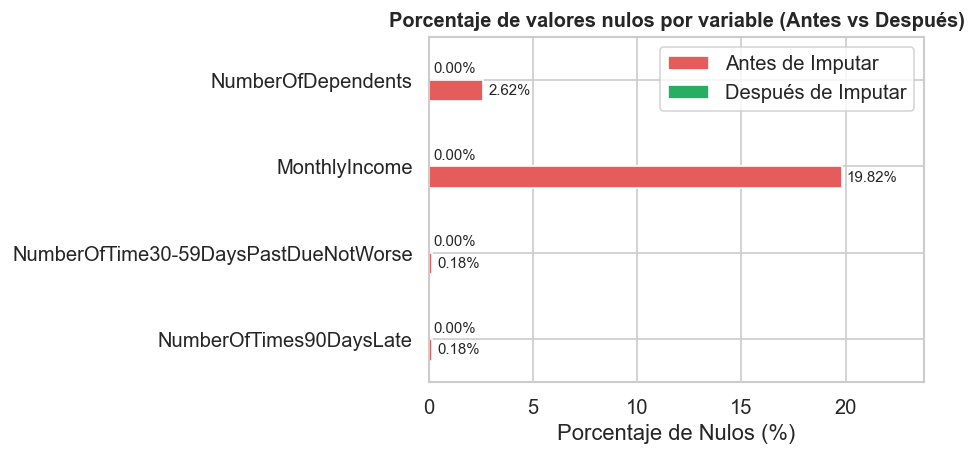

In [8]:
# Porcentaje de nulos después de imputar
nulos_despues_imputacion = (df.isnull().sum() / len(df) * 100).round(2)

# Variables que tenían nulos antes del proceso
vars_con_nulos = nulos_antes_imputacion[nulos_antes_imputacion > 0].index

df_nulos_comp = pd.DataFrame({
    'Antes de Imputar': nulos_antes_imputacion[vars_con_nulos],
    'Después de Imputar': nulos_despues_imputacion[vars_con_nulos]
})

fig, ax = plt.subplots(figsize=(8, 4))
df_nulos_comp.plot(kind='barh', color=['#E55C5C', '#27AE60'], ax=ax, edgecolor='white', width=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9)

ax.set_title('Porcentaje de valores nulos por variable (Antes vs Después)', fontsize=12, fontweight='bold')
ax.set_xlabel('Porcentaje de Nulos (%)')
ax.set_xlim(0, max(nulos_antes_imputacion[vars_con_nulos].max() * 1.2, 5))

plt.tight_layout()
plt.show()


---
## 5. Winsorización de outliers

Aplicamos **winsorización al percentil 99** en las variables con outliers extremos en el EDA. La winsorización recorta los valores — no los elimina — preservando todos los registros.

**Justificación técnica (Winsorización al percentil 99):** En lugar de eliminar outliers (lo que restaría representatividad e información valiosa sobre clientes de alto riesgo), la winsorización recorta los valores extremos al percentil 99. Esto acota el impacto de anomalías extremas sin sacrificar datos.

In [6]:
def winsorizacion(df, columna, percentil=0.99):
    """Recorta los valores de una columna al percentil indicado."""
    cap = df[columna].quantile(percentil)
    n_afectados = (df[columna] > cap).sum()
    df[columna] = df[columna].clip(upper=cap)
    print(f' {columna}: cap en {cap:.4f} — {n_afectados:,} valores recortados')
    return df

cols_winsorizacion = [
    'ResolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
]
cols_winsorizacion_presentes = [c for c in cols_winsorizacion if c in df.columns]

# Guardamos copia para la comparación visual
df_antes_winsor = df[cols_winsorizacion_presentes].copy()

print('=== Winsorización al percentil 99 ===')
for col in cols_winsorizacion_presentes:
    df = winsorizacion(df, col)


=== Winsorización al percentil 99 ===
 DebtRatio: cap en 4979.0400 — 1,500 valores recortados
 MonthlyIncome: cap en 23000.0000 — 1,499 valores recortados


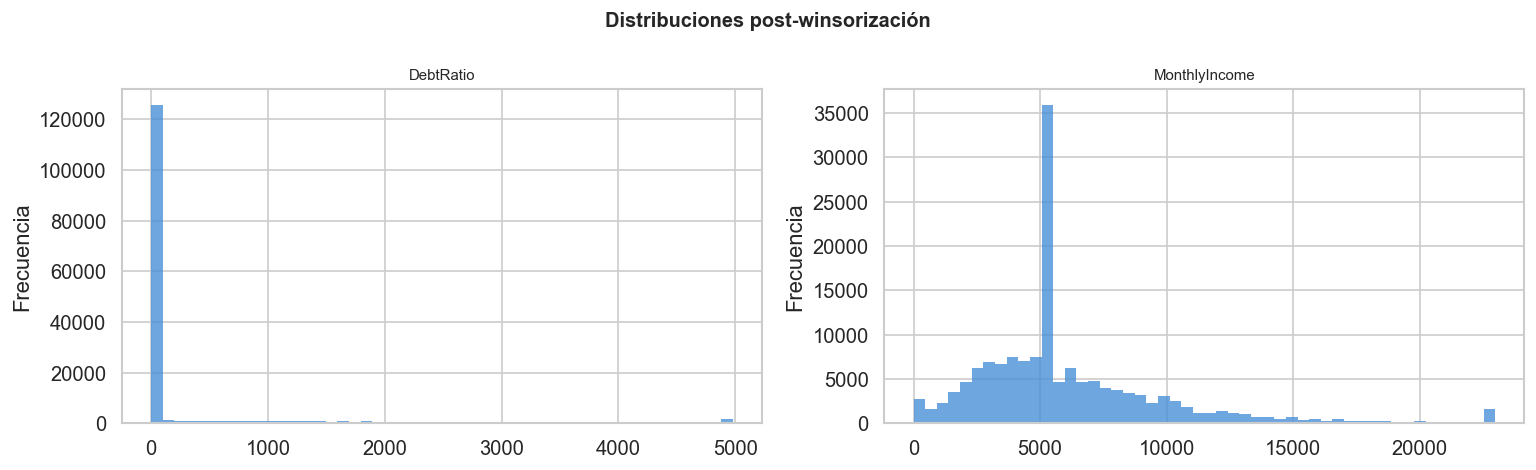

In [7]:
# Verificación visual — Comparación Antes vs Después de Winsorización
fig, axes = plt.subplots(len(cols_winsorizacion_presentes), 2, figsize=(12, 10))

for i, col in enumerate(cols_winsorizacion_presentes):
    # Antes (datos guardados antes de winsorizar)
    axes[i, 0].hist(df_antes_winsor[col], bins=50, color='#E55C5C', edgecolor='none', alpha=0.8)
    axes[i, 0].set_title(f'{col} — Antes (Original)', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Frecuencia')
    
    # Después (datos en df actual, winsorizados)
    axes[i, 1].hist(df[col], bins=50, color='#27AE60', edgecolor='none', alpha=0.8)
    axes[i, 1].set_title(f'{col} — Después (Winsorizado al 99%)', fontsize=10, fontweight='bold')

plt.suptitle('Comparación de Distribuciones (Antes vs Después de Winsorización)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Exportar dataset limpio

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/data_clean.csv', index=False)

print(f'Dataset limpio exportado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print('Ruta: data/processed/data_clean.csv')
print()
print('=== Resumen del dataset limpio ===')
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))

Dataset limpio exportado: 150,000 filas x 10 columnas
Ruta: data/processed/data_clean.csv

=== Resumen del dataset limpio ===
                                         mean      std   min      50%  \
RevolvingUtilizationOfUnsecuredLines     6.05   249.76   0.0     0.15   
NumberOfTimes90DaysLate                  0.09     0.49   0.0     0.00   
NumberOfTime30-59DaysPastDueNotWorse     0.25     0.70   0.0     0.00   
age                                     52.30    14.77  21.0    52.00   
NumberOfOpenCreditLinesAndLoans          8.45     5.15   0.0     8.00   
MonthlyIncome                         6142.45  3835.68   0.0  5400.00   
DebtRatio                              316.55   906.96   0.0     0.37   
NumberRealEstateLoansOrLines             1.02     1.13   0.0     1.00   
NumberOfDependents                       0.74     1.11   0.0     0.00   
SeriousDlqin2yrs                         0.07     0.25   0.0     0.00   

                                           max  
RevolvingUtilizationO

---
## Split train / test

Dividimos un 80% entrenamiento y 20% prueba usando **stratified split** para que ambos conjuntos mantengan la misma proporción de morosos (6.7%).
> El SMOTE se aplica **solo sobre el conjunto de entrenamiento.** Aplicarlo antes del split contaminaría el test set con datos sintéticos — Eso es data leakage.

**Justificación técnica (Stratified Split y SMOTE post-split):** La partición estratificada garantiza que la distribución del target (6.7% morosos) sea idéntica en train y test. SMOTE se aplica exclusivamente sobre train para evitar data leakage, asegurando que la evaluación en el test set sea con datos reales.

In [9]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print()
print('Distribución del target en train:')
print(y_train.value_counts(normalize=True).mul(100).round(2).to_string())
print()
print('Distribución del target en test:')
print(y_test.value_counts(normalize=True).mul(100).round(2).to_string())

Train: 120,000 filas | Test: 30,000 filas

Distribución del target en train:
SeriousDlqin2yrs
0    93.32
1     6.68

Distribución del target en test:
SeriousDlqin2yrs
0    93.32
1     6.68


---
## 8. Balanceo de clases con SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) genera observaciones sintéticas de la clase minoritaria (morosos) interpolando entre vecinos cercanos en el espacio de features.  
Lo aplicamos sobre `X_train` / `y_train` únicamente. El test set queda intacto con la distribución real.

In [10]:
print('Distribución ANTES de SMOTE (train):')
print(y_train.value_counts().to_string())
print(f'Ratio desbalance: {y_train.value_counts()[0] / y_train.value_counts()[1]:.1f}:1')
print()

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Distribución DESPUÉS de SMOTE (train):')
print(pd.Series(y_train_sm).value_counts().to_string())
print(f'Nuevas filas generadas: {len(X_train_sm) - len(X_train):,}')

Distribución ANTES de SMOTE (train):
SeriousDlqin2yrs
0    111979
1      8021
Ratio desbalance: 14.0:1

Distribución DESPUÉS de SMOTE (train):
SeriousDlqin2yrs
0    111979
1    111979
Nuevas filas generadas: 103,958


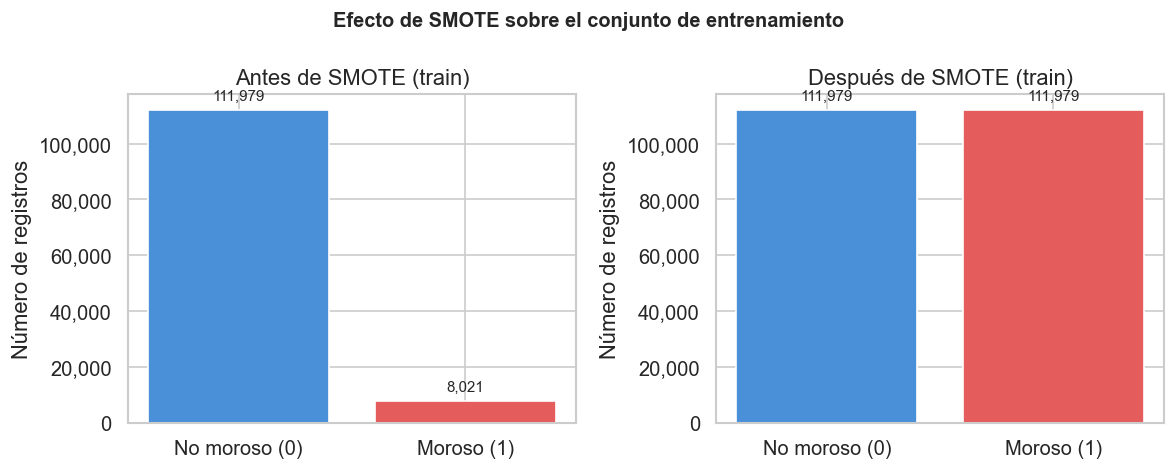

In [13]:
# Visualización del efecto de SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteos = [
    y_train.value_counts().values,
    pd.Series(y_train_sm).value_counts().values
]
titulos = ['Antes de SMOTE (train)', 'Después de SMOTE (train)']
colores = ['#4A90D9', '#E55C5C']
etiquetas = ['No moroso (0)', 'Moroso (1)']

for i, ax in enumerate(axes):
    bars = ax.bar(etiquetas, conteos[i], color=colores, edgecolor='white')
    ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
    ax.set_title(titulos[i])
    ax.set_ylabel('Número de registros')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Efecto de SMOTE sobre el conjunto de entrenamiento', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Verificación final y exportación

Verificamos que todo esté en orden y exportamos lso cuatro conjuntos de datos.

In [14]:
# Verificación: sin nulos en ningún conjunto
for nombre, conjunto in [('X_train_sm', X_train_sm), ('X_test', X_test)]:
    nulos = conjunto.isnull().sum().sum()
    estado = '✓ Sin nulos' if nulos == 0 else f'✗ {nulos} nulos detectados'
    print(f'{nombre}: {estado}')

print()

# Resumen de dimensiones finales
print('=== Dimensiones finales ===')
print(f'X_train (post-SMOTE): {X_train_sm.shape}')
print(f'y_train (post-SMOTE): {pd.Series(y_train_sm).shape}')
print(f'X_test (sin SMOTE): {X_test.shape}')
print(f'y_test (sin SMOTE): {y_test.shape}')

X_train_sm: ✓ Sin nulos
X_test: ✓ Sin nulos

=== Dimensiones finales ===
X_train (post-SMOTE): (223958, 9)
y_train (post-SMOTE): (223958,)
X_test (sin SMOTE): (30000, 9)
y_test (sin SMOTE): (30000,)


In [15]:
# Exportar dataset balanceado (train)
df_train_smote = X_train_sm.copy()
df_train_smote[TARGET] = y_train_sm
df_train_smote.to_csv('../data/processed/data_smote.csv', index=False)

# Exportar test set
df_test = X_test.copy()
df_test[TARGET] = y_test
df_test.to_csv('../data/processed/data_test.csv', index=False)

print('Archivos exportados:')
print('  ✓ data/processed/data_clean.csv   — dataset completo limpio')
print('  ✓ data/processed/data_smote.csv   — train set post-SMOTE')
print('  ✓ data/processed/data_test.csv    — test set (sin tocar)')
print()
print('Siguiente paso: Notebook 03 — Modelado')

Archivos exportados:
  ✓ data/processed/data_clean.csv   — dataset completo limpio
  ✓ data/processed/data_smote.csv   — train set post-SMOTE
  ✓ data/processed/data_test.csv    — test set (sin tocar)

Siguiente paso: Notebook 03 — Modelado
